# Klasifikasi Stunting pada Balita Menggunakan SMOTE dan Random Forest
**Dataset:** DAFTAR BNBA GONDANGREJO  
**Target:** TB/U → label biner Stunting (1) / Normal (0)  
**Algoritma Utama:** Random Forest + SMOTE  
**Pembanding:** Decision Tree, KNN, Naive Bayes, SVM

## 1. Instalasi dan Import Library

In [ ]:
!pip install imbalanced-learn openpyxl --quiet

import re
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.patches import Patch

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score,
    accuracy_score, precision_score, recall_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Load Dataset

In [ ]:
FILE_PATH = '/content/drive/MyDrive/Skripsi/DAFTAR BNBA GONDANGREJO (1).xls'
df_raw = pd.read_excel(FILE_PATH, header=1)
df_raw.columns = df_raw.columns.str.strip()

print(f'Shape  : {df_raw.shape}')
print(f'Kolom  : {df_raw.columns.tolist()}')
df_raw.head(3)

Shape  : (4820, 14)
Kolom  : ['No', 'Nama', 'JK', 'Tgl Lahir', 'Desa/Kel', 'Usia Saat Ukur', 'Tanggal Pengukuran', 'Berat', 'Tinggi', 'Cara Ukur', 'BB/U', 'TB/U', 'BB/TB', 'Naik Berat Badan']


,No,Nama,JK,Tgl Lahir,Desa/Kel,Usia Saat Ukur,Tanggal Pengukuran,Berat,Tinggi,Cara Ukur,BB/U,TB/U,BB/TB,Naik Berat Badan
0,1.0,NAURA,L,2020-12-22,SELOKATON,4 Tahun - 7 Bulan - 21 Hari,2025-08-12,19.0,108.7,Berdiri,Normal,Normal,Gizi Baik,T
1,2.0,AYRA PUTRI DORI,P,2020-09-21,JERUKSAWIT,4 Tahun - 10 Bulan - 18 Hari,2025-08-08,16.2,102.4,Berdiri,Normal,Normal,Gizi Baik,N
2,3.0,abian,L,2020-12-14,JERUKSAWIT,4 Tahun - 7 Bulan - 25 Hari,2025-08-08,14.2,101.7,Berdiri,Normal,Normal,Gizi Baik,N


## 3. Eksplorasi Data Awal

In [ ]:
print('=== Missing Values ===')
print(df_raw.isnull().sum())

print('\n=== Distribusi TB/U (Label Target) ===')
print(df_raw['TB/U'].value_counts())

print('\n=== Distribusi BB/U ===')
print(df_raw['BB/U'].value_counts())

print('\n=== Distribusi BB/TB ===')
print(df_raw['BB/TB'].value_counts())

print('\n=== Distribusi Cara Ukur ===')
print(df_raw['Cara Ukur'].value_counts())

print('\n=== Distribusi Naik Berat Badan ===')
print(df_raw['Naik Berat Badan'].value_counts())

=== Missing Values ===
No                    0
Nama                  0
JK                    0
Tgl Lahir             0
Desa/Kel              0
Usia Saat Ukur        0
Tanggal Pengukuran    0
Berat                 0
Tinggi                0
Cara Ukur             0
BB/U                  0
TB/U                  0
BB/TB                 0
Naik Berat Badan      0
dtype: int64

=== Distribusi TB/U (Label Target) ===
TB/U
Normal           4667
Pendek            125
Sangat Pendek      16
Tinggi              9
-                   3
Name: count, dtype: int64

=== Distribusi BB/U ===
BB/U
Normal           4317
Risiko Lebih      283
Kurang            203
Sangat Kurang      13
-                   3
Outlier             1
Name: count, dtype: int64

=== Distribusi BB/TB ===
BB/TB
Gizi Baik            3746
Risiko Gizi Lebih     738
Gizi Lebih            176
Gizi Kurang           111
Obesitas               45
-                       3
Outlier                 1
Name: count, dtype: int64

=== Distribusi Car

## 4. Pre-Processing

In [ ]:
df = df_raw.copy()

# Hapus baris tidak valid
baris_awal = len(df)
df = df[~df['TB/U'].isin(['-', 'Outlier'])]
df = df[~df['BB/U'].isin(['-', 'Outlier'])]
df = df[~df['BB/TB'].isin(['-', 'Outlier'])]
print(f'Baris dihapus (tidak valid): {baris_awal - len(df)} | Sisa: {len(df)}')

# Parsing usia ke satuan bulan
def parse_usia(usia_str):
    try:
        nums = [int(x) for x in re.findall(r'\d+', str(usia_str))]
        return nums[0] * 12 + nums[1] if len(nums) >= 2 else (nums[0] if nums else 0)
    except:
        return 0

df['Usia_Bulan'] = df['Usia Saat Ukur'].apply(parse_usia)

# Koreksi tinggi badan (standar WHO ±0,7 cm)
def koreksi_tinggi(row):
    cara = str(row['Cara Ukur']).strip().lower()
    usia = row['Usia_Bulan']
    t    = row['Tinggi']
    if usia > 24 and 'terlentang' in cara:
        return t - 0.7
    elif usia <= 24 and 'berdiri' in cara:
        return t + 0.7
    return t

df['Tinggi_Koreksi'] = df.apply(koreksi_tinggi, axis=1)

# Buat label target: Stunting (1) / Normal (0)
df['Stunting'] = df['TB/U'].apply(
    lambda x: 1 if str(x).strip().lower() in ['pendek', 'sangat pendek'] else 0
)

# Label encoding fitur kategorikal
le_jk   = LabelEncoder()
le_bbu  = LabelEncoder()
le_bbtb = LabelEncoder()
le_cara = LabelEncoder()
le_nbb  = LabelEncoder()

df['JK_Enc']   = le_jk.fit_transform(df['JK'].astype(str))
df['BBU_Enc']  = le_bbu.fit_transform(df['BB/U'].astype(str))
df['BBTB_Enc'] = le_bbtb.fit_transform(df['BB/TB'].astype(str))
df['Cara_Enc'] = le_cara.fit_transform(df['Cara Ukur'].astype(str))
df['NBB_Enc']  = le_nbb.fit_transform(df['Naik Berat Badan'].astype(str))

# Imputasi missing value numerik dengan median
for col in ['Berat', 'Tinggi_Koreksi', 'Usia_Bulan']:
    df[col].fillna(df[col].median(), inplace=True)

print('\n✅ Pre-processing selesai')
print(f'Shape akhir : {df.shape}')
print('\nDistribusi label:')
print(df['Stunting'].value_counts().rename({0:'Normal', 1:'Stunting'}))

Baris dihapus (tidak valid): 4 | Sisa: 4816

✅ Pre-processing selesai
Shape akhir : (4816, 22)

Distribusi label:
Stunting
Normal      4675
Stunting     141
Name: count, dtype: int64


/tmp/ipykernel_1152/2078760812.py:53: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
print(df['Tinggi_Koreksi'])

0       108.7
1       102.4
2       101.7
3       103.0
4       118.0
        ...  
4815     65.0
4816     46.0
4817     66.0
4818     98.0
4819     47.0
Name: Tinggi_Koreksi, Length: 4816, dtype: float64


In [ ]:
print('--- After parsing age and correcting height ---')
print(df[['Usia Saat Ukur', 'Usia_Bulan', 'Tinggi', 'Tinggi_Koreksi', 'Cara Ukur']].head())

print('\n--- After label encoding categorical features ---')
print(df[['JK', 'JK_Enc', 'BB/U', 'BBU_Enc', 'BB/TB', 'BBTB_Enc', 'Cara Ukur', 'Cara_Enc', 'Naik Berat Badan', 'NBB_Enc']].head())

print('\n--- Label Encoding Mappings ---')
print(f"JK (Original -> Encoded): {list(le_jk.classes_)} -> {list(range(len(le_jk.classes_)))}")
print(f"BB/U (Original -> Encoded): {list(le_bbu.classes_)} -> {list(range(len(le_bbu.classes_)))}")
print(f"BB/TB (Original -> Encoded): {list(le_bbtb.classes_)} -> {list(range(len(le_bbtb.classes_)))}")
print(f"Cara Ukur (Original -> Encoded): {list(le_cara.classes_)} -> {list(range(len(le_cara.classes_)))}")
print(f"Naik Berat Badan (Original -> Encoded): {list(le_nbb.classes_)} -> {list(range(len(le_nbb.classes_)))}")


--- After parsing age and correcting height ---
                 Usia Saat Ukur  Usia_Bulan  Tinggi  Tinggi_Koreksi Cara Ukur
0   4 Tahun - 7 Bulan - 21 Hari          55   108.7           108.7   Berdiri
1  4 Tahun - 10 Bulan - 18 Hari          58   102.4           102.4   Berdiri
2   4 Tahun - 7 Bulan - 25 Hari          55   101.7           101.7   Berdiri
3  4 Tahun - 10 Bulan - 27 Hari          58   103.0           103.0   Berdiri
4  4 Tahun - 11 Bulan - 29 Hari          59   118.0           118.0   Berdiri

--- After label encoding categorical features ---
  JK  JK_Enc    BB/U  BBU_Enc      BB/TB  BBTB_Enc Cara Ukur  Cara_Enc  \
0  L       0  Normal        1  Gizi Baik         0   Berdiri         1   
1  P       1  Normal        1  Gizi Baik         0   Berdiri         1   
2  L       0  Normal        1  Gizi Baik         0   Berdiri         1   
3  P       1  Normal        1  Gizi Baik         0   Berdiri         1   
4  L       0  Normal        1  Gizi Baik         0   Berdiri   

## 5. Definisi Fitur (X) dan Label (y)

In [ ]:
FEATURE_COLS = [
    'JK_Enc',         # Jenis kelamin
    'Usia_Bulan',     # Usia dalam bulan
    'Berat',          # Berat badan (kg)
    'Tinggi_Koreksi', # Tinggi badan terkoreksi (cm)
    'Cara_Enc',       # Cara pengukuran
    'BBU_Enc',        # Status BB/U
    'BBTB_Enc',       # Status BB/TB
    'NBB_Enc',        # Naik Berat Badan
]

X = df[FEATURE_COLS]
y = df['Stunting']

print(f'Jumlah fitur  : {len(FEATURE_COLS)}')
print(f'Fitur input   : {FEATURE_COLS}')
print(f'Total sampel  : {len(X)}')
print(f'\nDistribusi y:')
print(y.value_counts().rename({0:'Normal (0)', 1:'Stunting (1)'}))
print(f'\nRasio ketidakseimbangan: {y.value_counts()[0]}:{y.value_counts()[1]} '
      f'({y.value_counts()[0]/y.value_counts()[1]:.1f}:1)')

Jumlah fitur  : 8
Fitur input   : ['JK_Enc', 'Usia_Bulan', 'Berat', 'Tinggi_Koreksi', 'Cara_Enc', 'BBU_Enc', 'BBTB_Enc', 'NBB_Enc']
Total sampel  : 4816

Distribusi y:
Stunting
Normal (0)      4675
Stunting (1)     141
Name: count, dtype: int64

Rasio ketidakseimbangan: 4675:141 (33.2:1)


## 6. Distribusi Kelas Sebelum SMOTE

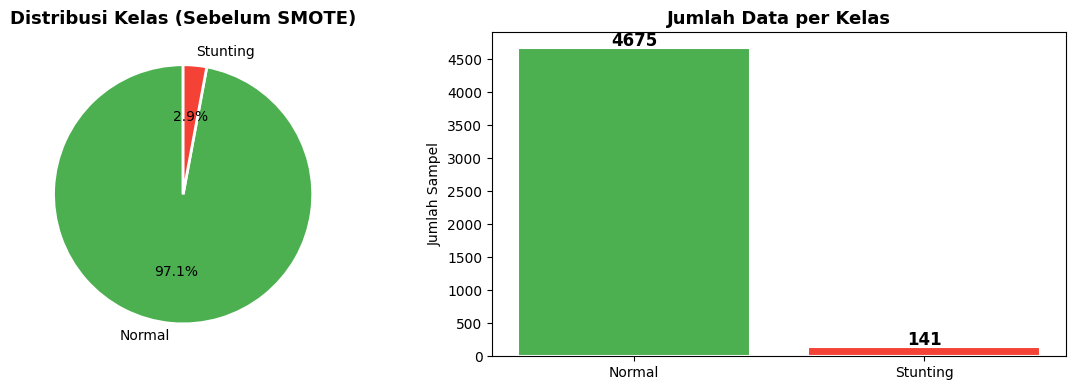

Normal   : 4,675 (97.1%)
Stunting : 141 (2.9%)
Rasio    : 33.2 : 1


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = y.value_counts().sort_index()
labels = ['Normal', 'Stunting']
colors = ['#4CAF50', '#F44336']

axes[0].pie(counts, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor':'white', 'linewidth':2})
axes[0].set_title('Distribusi Kelas (Sebelum SMOTE)', fontsize=13, fontweight='bold')

bars = axes[1].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 30,
                 str(v), ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Jumlah Data per Kelas', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Jumlah Sampel')
axes[1].yaxis.set_major_locator(ticker.MultipleLocator(500))

plt.tight_layout()
plt.savefig('distribusi_sebelum_smote.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Normal   : {counts[0]:,} ({counts[0]/len(y)*100:.1f}%)')
print(f'Stunting : {counts[1]:,} ({counts[1]/len(y)*100:.1f}%)')
print(f'Rasio    : {counts[0]/counts[1]:.1f} : 1')

## 7. Pembagian Data Train–Test (75:25, Stratified)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f'Total data   : {len(X):,}')
print(f'Data train   : {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)')
print(f'Data test    : {len(X_test):,}  ({len(X_test)/len(X)*100:.0f}%)')
print(f'\nKelas pada data train : {dict(y_train.value_counts().rename({0:"Normal", 1:"Stunting"}))}')
print(f'Kelas pada data test  : {dict(y_test.value_counts().rename({0:"Normal", 1:"Stunting"}))}')

Total data   : 4,816
Data train   : 3,612 (75%)
Data test    : 1,204  (25%)

Kelas pada data train : {'Normal': np.int64(3506), 'Stunting': np.int64(106)}
Kelas pada data test  : {'Normal': np.int64(1169), 'Stunting': np.int64(35)}


## 8. Penerapan SMOTE pada Data Training

In [ ]:
smote = SMOTE(k_neighbors=5, random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('Distribusi SEBELUM SMOTE (train):', dict(y_train.value_counts()))
print('Distribusi SESUDAH  SMOTE (train):', dict(pd.Series(y_train_sm).value_counts()))
print(f'\nTotal data train setelah SMOTE: {len(X_train_sm):,}')

Distribusi SEBELUM SMOTE (train): {0: np.int64(3506), 1: np.int64(106)}
Distribusi SESUDAH  SMOTE (train): {0: np.int64(3506), 1: np.int64(3506)}

Total data train setelah SMOTE: 7,012


## 9. Distribusi Kelas Sesudah SMOTE

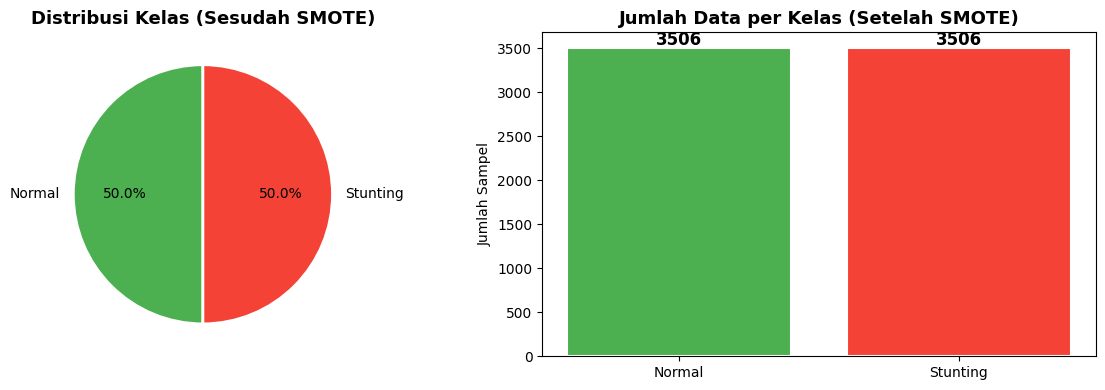

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts_sm = pd.Series(y_train_sm).value_counts().sort_index()
labels = ['Normal', 'Stunting']
colors = ['#4CAF50', '#F44336']

axes[0].pie(counts_sm, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor':'white', 'linewidth':2})
axes[0].set_title('Distribusi Kelas (Sesudah SMOTE)', fontsize=13, fontweight='bold')

bars = axes[1].bar(labels, counts_sm.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, counts_sm.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 30,
                 str(v), ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Jumlah Data per Kelas (Setelah SMOTE)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Jumlah Sampel')

plt.tight_layout()
plt.savefig('distribusi_sesudah_smote.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Normalisasi Fitur (MinMaxScaler)

In [ ]:
scaler = MinMaxScaler()

X_train_sc    = scaler.fit_transform(X_train)
X_test_sc     = scaler.transform(X_test)

# Fit ulang scaler pada data train post-SMOTE untuk digunakan model utama
scaler_sm     = MinMaxScaler()
X_train_sm_sc = scaler_sm.fit_transform(X_train_sm)
X_test_sm_sc  = scaler_sm.transform(X_test)

print('✅ Normalisasi selesai')
print(f'X_train_sm_sc shape : {X_train_sm_sc.shape}')
print(f'X_test_sm_sc  shape : {X_test_sm_sc.shape}')

✅ Normalisasi selesai
X_train_sm_sc shape : (7012, 8)
X_test_sm_sc  shape : (1204, 8)


## 11. Model Utama: Random Forest

In [ ]:
# ── Random Forest TANPA SMOTE ──────────────────────────────────────────
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base.fit(X_train_sc, y_train)
y_pred_rf_base = rf_base.predict(X_test_sc)

print('=' * 60)
print('  Random Forest — TANPA SMOTE')
print('=' * 60)
print(classification_report(y_test, y_pred_rf_base,
      target_names=['Normal', 'Stunting'], zero_division=0))

# ── Random Forest DENGAN SMOTE ─────────────────────────────────────────
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_sm_sc, y_train_sm)
y_pred_rf_smote = rf_smote.predict(X_test_sm_sc)

print('=' * 60)
print('  Random Forest — DENGAN SMOTE')
print('=' * 60)
print(classification_report(y_test, y_pred_rf_smote,
      target_names=['Normal', 'Stunting'], zero_division=0))

  Random Forest — TANPA SMOTE
              precision    recall  f1-score   support

      Normal       0.97      1.00      0.99      1169
    Stunting       0.62      0.14      0.23        35

    accuracy                           0.97      1204
   macro avg       0.80      0.57      0.61      1204
weighted avg       0.96      0.97      0.96      1204

  Random Forest — DENGAN SMOTE
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98      1169
    Stunting       0.45      0.40      0.42        35

    accuracy                           0.97      1204
   macro avg       0.72      0.69      0.70      1204
weighted avg       0.97      0.97      0.97      1204



## 12. Confusion Matrix — Random Forest

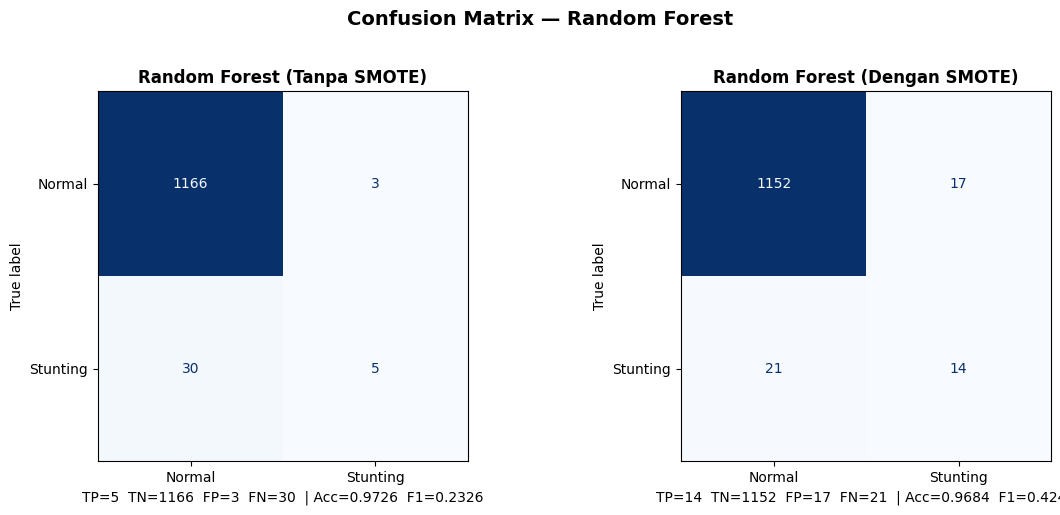

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_rf_base, y_pred_rf_smote],
    ['Random Forest (Tanpa SMOTE)', 'Random Forest (Dengan SMOTE)']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Normal', 'Stunting'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12, fontweight='bold')
    # Tambahkan anotasi TP/TN/FP/FN
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(
        f'TP={tp}  TN={tn}  FP={fp}  FN={fn}  '
        f'| Acc={accuracy_score(y_test,y_pred):.4f}  '
        f'F1={f1_score(y_test,y_pred,zero_division=0):.4f}',
        fontsize=10
    )

plt.suptitle('Confusion Matrix — Random Forest', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrix_rf.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Perbandingan 5 Algoritma (dengan SMOTE)

In [ ]:
algoritma = {
    'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree' : DecisionTreeClassifier(criterion='gini', max_depth=6, random_state=42),
    'KNN'           : KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes'   : GaussianNB(),
    'SVM'           : SVC(kernel='rbf', random_state=42),
}

hasil = []
for nama, model in algoritma.items():
    model.fit(X_train_sm_sc, y_train_sm)
    y_pred_i = model.predict(X_test_sm_sc)

    acc  = accuracy_score(y_test, y_pred_i)
    prec = precision_score(y_test, y_pred_i, zero_division=0)
    rec  = recall_score(y_test, y_pred_i, zero_division=0)
    f1   = f1_score(y_test, y_pred_i, zero_division=0)

    hasil.append({'Algoritma':nama, 'Accuracy':acc,
                  'Precision':prec, 'Recall':rec, 'F1-Score':f1})
    print(f'[{nama:15s}]  Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}')

df_hasil = pd.DataFrame(hasil).sort_values('F1-Score', ascending=False).reset_index(drop=True)
print('\n=== Tabel Perbandingan (diurutkan F1-Score) ===')
print(df_hasil.to_string(index=False))

[Random Forest  ]  Acc=0.9684  Prec=0.4516  Rec=0.4000  F1=0.4242
[Decision Tree  ]  Acc=0.8256  Prec=0.1041  Rec=0.6571  F1=0.1797
[KNN            ]  Acc=0.9352  Prec=0.2208  Rec=0.4857  F1=0.3036
[Naive Bayes    ]  Acc=0.7110  Prec=0.0712  Rec=0.7429  F1=0.1300
[SVM            ]  Acc=0.9178  Prec=0.2288  Rec=0.7714  F1=0.3529

=== Tabel Perbandingan (diurutkan F1-Score) ===
    Algoritma  Accuracy  Precision   Recall  F1-Score
Random Forest  0.968439   0.451613 0.400000  0.424242
          SVM  0.917774   0.228814 0.771429  0.352941
          KNN  0.935216   0.220779 0.485714  0.303571
Decision Tree  0.825581   0.104072 0.657143  0.179688
  Naive Bayes  0.710963   0.071233 0.742857  0.130000


## 14. Visualisasi Perbandingan Algoritma

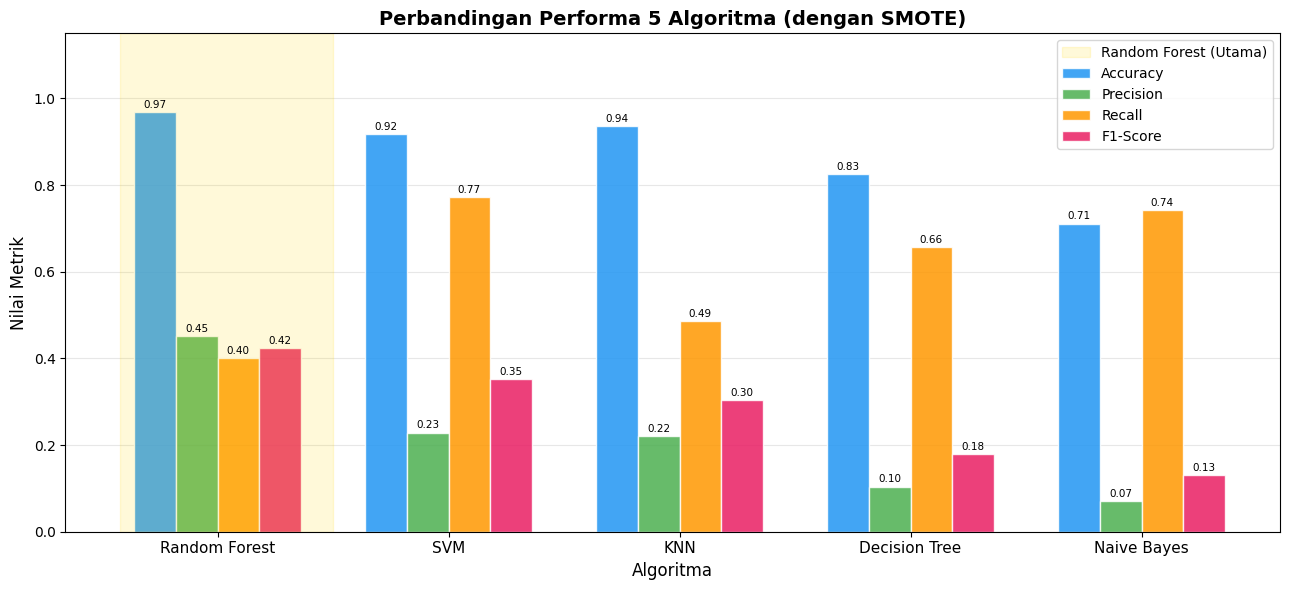

In [ ]:
metrics  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x        = np.arange(len(df_hasil))
width    = 0.18
colors   = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

fig, ax = plt.subplots(figsize=(13, 6))

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, df_hasil[metric], width,
                  label=metric, color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.2f}',
                ha='center', va='bottom', fontsize=7.5)

# Highlight kolom Random Forest
rf_idx = df_hasil[df_hasil['Algoritma'] == 'Random Forest'].index[0]
ax.axvspan(rf_idx - 0.15, rf_idx + 4*width + 0.05,
           color='gold', alpha=0.15, label='Random Forest (Utama)')

ax.set_xlabel('Algoritma', fontsize=12)
ax.set_ylabel('Nilai Metrik', fontsize=12)
ax.set_title('Perbandingan Performa 5 Algoritma (dengan SMOTE)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_hasil['Algoritma'], fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right', fontsize=10)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('perbandingan_algoritma.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Cross-Validation (Stratified K-Fold, k=5)
SMOTE diintegrasikan di dalam `ImbPipeline` sehingga diterapkan **independen di setiap fold** — menghindari data leakage ke fold validasi.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_hasil = []
for nama, clf in algoritma.items():
    pipe = ImbPipeline([
        ('scaler', MinMaxScaler()),
        ('smote',  SMOTE(k_neighbors=5, random_state=42)),
        ('model',  clf)
    ])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='f1', n_jobs=-1)
    cv_hasil.append({
        'Algoritma'  : nama,
        'CV F1 Mean' : scores.mean(),
        'CV F1 Std'  : scores.std()
    })
    print(f'[{nama:15s}]  CV F1 = {scores.mean():.4f} ± {scores.std():.4f}')

df_cv = pd.DataFrame(cv_hasil).sort_values('CV F1 Mean', ascending=False).reset_index(drop=True)
print('\n=== Ringkasan Cross-Validation ===')
print(df_cv.to_string(index=False))

[Random Forest  ]  CV F1 = 0.5105 ± 0.0953
[Decision Tree  ]  CV F1 = 0.1927 ± 0.0270
[KNN            ]  CV F1 = 0.3301 ± 0.0576
[Naive Bayes    ]  CV F1 = 0.1128 ± 0.0097
[SVM            ]  CV F1 = 0.3136 ± 0.0136

=== Ringkasan Cross-Validation ===
    Algoritma  CV F1 Mean  CV F1 Std
Random Forest    0.510503   0.095258
          KNN    0.330059   0.057563
          SVM    0.313614   0.013613
Decision Tree    0.192741   0.027036
  Naive Bayes    0.112758   0.009726


## 16. Feature Importance — Random Forest
Dihitung dari rata-rata penurunan Gini impurity di 100 pohon.

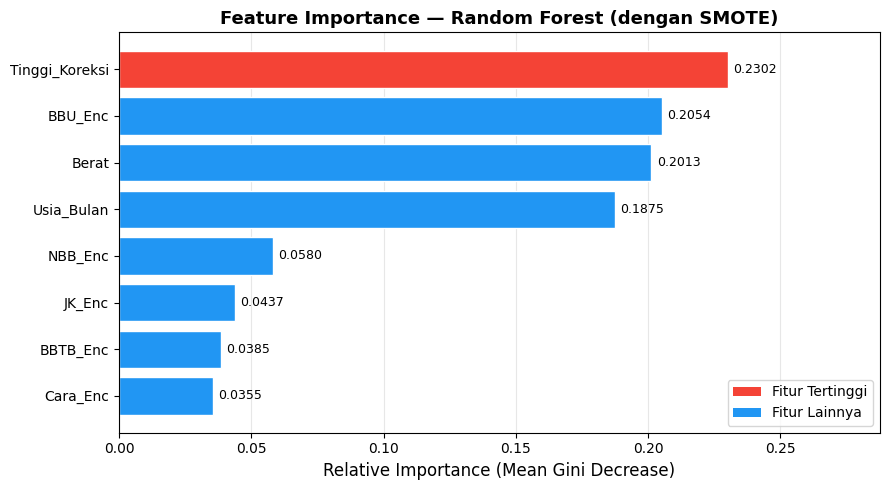


=== Peringkat Feature Importance ===
  Tinggi_Koreksi      : 0.2302 (23.02%)
  BBU_Enc             : 0.2054 (20.54%)
  Berat               : 0.2013 (20.13%)
  Usia_Bulan          : 0.1875 (18.75%)
  NBB_Enc             : 0.0580 (5.80%)
  JK_Enc              : 0.0437 (4.37%)
  BBTB_Enc            : 0.0385 (3.85%)
  Cara_Enc            : 0.0355 (3.55%)


In [ ]:
importances = rf_smote.feature_importances_
sorted_idx  = np.argsort(importances)

colors_bar = ['#F44336' if importances[i] == importances.max() else '#2196F3'
              for i in sorted_idx]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    [FEATURE_COLS[i] for i in sorted_idx],
    importances[sorted_idx],
    color=colors_bar,
    edgecolor='white'
)
for bar, v in zip(bars, importances[sorted_idx]):
    ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=9)

ax.set_xlabel('Relative Importance (Mean Gini Decrease)', fontsize=12)
ax.set_title('Feature Importance — Random Forest (dengan SMOTE)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, importances.max() * 1.25)
ax.xaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#F44336', label='Fitur Tertinggi'),
                   Patch(facecolor='#2196F3', label='Fitur Lainnya')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Peringkat Feature Importance ===')
for i in sorted_idx[::-1]:
    print(f'  {FEATURE_COLS[i]:20s}: {importances[i]:.4f} ({importances[i]*100:.2f}%)')

## 17. Ringkasan Hasil Akhir

In [ ]:
print('=' * 65)
print('  RINGKASAN HASIL PENELITIAN')
print('=' * 65)
print(f'  Total data           : {len(X):,}')
print(f'  Stunting (raw)       : {y.sum()} ({y.mean()*100:.1f}%)')
print(f'  Normal   (raw)       : {(y==0).sum()} ({(y==0).mean()*100:.1f}%)')
print(f'  Rasio ketidakseimb.  : {(y==0).sum()/y.sum():.1f}:1')
print(f'  Data train (75%)     : {len(X_train):,}')
print(f'  Data test  (25%)     : {len(X_test):,}')
print(f'  Data train + SMOTE   : {len(X_train_sm):,} (seimbang {pd.Series(y_train_sm).value_counts()[0]}:{pd.Series(y_train_sm).value_counts()[1]})')
print()
print('  ── Random Forest + SMOTE (Data Uji) ──────────────────')
rf_acc  = accuracy_score(y_test, y_pred_rf_smote)
rf_prec = precision_score(y_test, y_pred_rf_smote, zero_division=0)
rf_rec  = recall_score(y_test, y_pred_rf_smote, zero_division=0)
rf_f1   = f1_score(y_test, y_pred_rf_smote, zero_division=0)
print(f'  Accuracy   : {rf_acc:.4f} ({rf_acc*100:.2f}%)')
print(f'  Precision  : {rf_prec:.4f} ({rf_prec*100:.2f}%)')
print(f'  Recall     : {rf_rec:.4f} ({rf_rec*100:.2f}%)')
print(f'  F1-Score   : {rf_f1:.4f}')
cm_rf = confusion_matrix(y_test, y_pred_rf_smote)
tn,fp,fn,tp = cm_rf.ravel()
print(f'  TP={tp}  TN={tn}  FP={fp}  FN={fn}')
print()
print('  ── Cross-Validation (Random Forest) ──────────────────')
rf_cv = df_cv[df_cv['Algoritma']=='Random Forest'].iloc[0]
print(f'  CV F1 Mean : {rf_cv["CV F1 Mean"]:.4f}')
print(f'  CV F1 Std  : ±{rf_cv["CV F1 Std"]:.4f}')
print()
print('  ── Algoritma Terbaik (F1-Score) ───────────────────────')
best = df_hasil.iloc[0]
print(f'  {best["Algoritma"]:15s}: F1={best["F1-Score"]:.4f}  Acc={best["Accuracy"]:.4f}')
print('=' * 65)

  RINGKASAN HASIL PENELITIAN
  Total data           : 4,816
  Stunting (raw)       : 141 (2.9%)
  Normal   (raw)       : 4675 (97.1%)
  Rasio ketidakseimb.  : 33.2:1
  Data train (75%)     : 3,612
  Data test  (25%)     : 1,204
  Data train + SMOTE   : 7,012 (seimbang 3506:3506)

  ── Random Forest + SMOTE (Data Uji) ──────────────────
  Accuracy   : 0.9684 (96.84%)
  Precision  : 0.4516 (45.16%)
  Recall     : 0.4000 (40.00%)
  F1-Score   : 0.4242
  TP=14  TN=1152  FP=17  FN=21

  ── Cross-Validation (Random Forest) ──────────────────
  CV F1 Mean : 0.5105
  CV F1 Std  : ±0.0953

  ── Algoritma Terbaik (F1-Score) ───────────────────────
  Random Forest  : F1=0.4242  Acc=0.9684


In [ ]:
import pickle
SAVE_DIR = '/content/drive/MyDrive/models'
os.makedirs(SAVE_DIR, exist_ok=True)

with open(f'{SAVE_DIR}/rf_model.pkl', 'wb') as f:
    pickle.dump(rf_smote, f)

with open(f'{SAVE_DIR}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler_sm, f)

print("✅ Model tersimpan di Google Drive")

✅ Model tersimpan di Google Drive
